# Tutorial 3 - Tracking ghosts across parameter changes

Another useful feature of PyGhostID is the ability to follow identified ghosts in parameter space as one of the system parameters is changed using the function  `track_ghost_branch`. The basic principle is simple: starting with an identified ghost $G_0$ at parameter $p_0$, the function changes the parameter value by small step to $p_0 + \Delta p$, searches the for the slowest point in phase space within distance $\delta$ of $G_0$'s position in phase space as a candidate ghost, simulates a trajectory within the attracting sector of the candidate ghost and runs `ghostID` on the trajectory. If a ghost is found at parameter $p_0 + \Delta p$, the process is repeated until no more ghost is found or the maximum number of repeats is reached.

To illustrate the use of `track_ghost_branch`, we will reproduce Figure 4b from [Koch & Nandan 2026](https://arxiv.org/abs/2604.05194). The system we're analyzing are two identical and coupled theta-neurons as described in [Augustsson & Martens 2024](https://doi.org/10.1063/5.0226338). From the paper, we know the system has a saddle-node bifurcation at $\eta=0$ in which two saddles, a sink and a repeller coalesce. To begin with we thus launch a trajectory at the parameter value $\eta=0.01$ for which we expect to find a ghost:

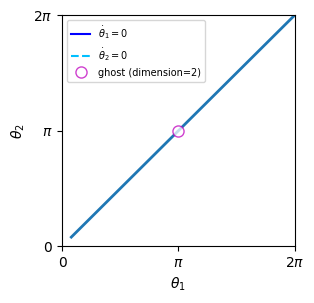

In [1]:
# imports
import numpy as np
import jax.numpy as jnp
from scipy.integrate import solve_ivp
import PyGhostID as gid
import matplotlib.pyplot as plt

def coupledThetaNeurons(t, z, para): # from Augustsson & Martens 2024, doi: 10.1063/5.0226338
    n,K,pS = para
    theta1_dot = 1-jnp.cos(z[0]+pS)+(1+jnp.cos(z[0]+pS))*(n+K*(1-jnp.cos(z[1]+pS))) 
    theta2_dot = 1-jnp.cos(z[1]+pS)+(1+jnp.cos(z[1]+pS))*(n+K*(1-jnp.cos(z[0]+pS))) 
    return jnp.array([theta1_dot,theta2_dot])

# set parameters
n = 0.01; K = 0.1; pS = np.pi
parameters_theta =  [n,K,pS]

# simulate trajectory 
dt = 0.005
timesteps = np.linspace(0,30,int(30/dt))
sol = solve_ivp(coupledThetaNeurons, (0, 30), [0.25,0.25],
                    t_eval=timesteps, args=(parameters_theta,),method='RK45',rtol=1e-4,atol=1e-6)

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(coupledThetaNeurons,parameters_theta,dt,Trj,peak_kwargs={"prominence":0,"width":50},eigval_NN_sorting=True,ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

#  plot phase space
xmin=0;xmax=2*np.pi
ymin=0;ymax=2*np.pi

Ng=200
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

plt.figure(figsize=(3,3))
ax = plt.gca()

# plot trajectory
ax.plot(sol.y[0],sol.y[1],'-',lw=2)

# nullclines
f1,f2 = coupledThetaNeurons(0,jnp.array([Xg,Yg]),parameters_theta)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot\theta_1 = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot\theta_2 = 0$')

# plot ghost
gx,gy = ghostSeq[0]["position"]
ax.plot(gx,gy,'ow',mec='m',markersize=8,alpha=0.75,label=f'ghost (dimension={ghostSeq[0]["dimension"]})')


#labels, limits, legend
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_xlim(xmin,xmax); ax.set_xticks([0,np.pi,2*np.pi]); ax.set_xticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.set_ylim(ymin,ymax); ax.set_yticks([0,np.pi,2*np.pi]); ax.set_yticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.legend(fontsize=7)

plt.show()


Next, we will use this ghost as a starting point and track it as we increase $\eta$. We start only with the mandatory arguments: the ghost to start with, the model function, the model parameters, the index of the parameter to be changes (in our case 0), the number of steps (i.e. how often the parameter should be increased or decreased), the stepsize of the parameter change ($\Delta p$), the duration of the trajectory and the temporal stepsize.

In [2]:
ghost_start = ghostSeq[0]
positions_ghosts, paramVals, ghostSeqs =  gid.track_ghost_branch(ghost_start, coupledThetaNeurons, parameters_theta, 0, 20, 0.05, 25, dt)

Progress:  10.00% | param value=0.11000:  10%|▉         | 2/21 [00:03<00:32,  1.71s/it]

GhostID: Trajectory does not leave U_eps - stopping ghostID.


Progress:  60.00% | param value=0.61000:  57%|█████▋    | 12/21 [00:21<00:15,  1.76s/it]

Terminating track_ghost_branch: Error in chosing initial conditions around qmin (both trajectories are diverging). Try different global/local method/options for finding qmin or different icStep size.


From the progress bar we can see that function sucessfully finished the first couple of iterations before an error occurs. The error message indicates that the algorithm failed to initialize a trajectory within the ghost's attracting sector which could be because it didn't find the right slow point in phase space to start from or because the trajectory started to close or too far from the identified slow point. It thus suggests to either change the methods for finding the slow point (qmin) or the distance from the slow point from which the trajectory is started (`icStep`). We will begin with the first of the two suggestions. We increase the search radius for slow points to `delta=0.35` and while we keep the default global method of searching for a slow point (latin hypercube sampling: `global_method ="lhs"`), we will increase the number of random samples to 150 while disabling local optimization. We also added a seed to the global search options for exact reproducibility.

In [3]:
positions_ghosts, paramVals, ghostSeqs =  gid.track_ghost_branch(ghost_start, coupledThetaNeurons, parameters_theta, 0, 20, 0.05, 25, dt, 
                                                                 delta=0.35, qmin_glob_options={"seed":9,"n_samples":150},qmin_loc_method=None)

Progress:  80.00% | param value=0.81000:  76%|███████▌  | 16/21 [00:13<00:04,  1.22it/s]

GhostID: Trajectory does not leave U_eps - stopping ghostID.


Progress: 100.00% | param value=1.01000: 100%|██████████| 21/21 [00:17<00:00,  1.17it/s]


This time the function runs until all iterations are completed, suggesting it successfully tracked the ghost we started from. Plotting the positions of the ghost versus parameter values along with the bifurcation diagram (data generated via XPPAUT and available in PyGhostID's github repository), however, suggests that the last ghost identified is out of place:

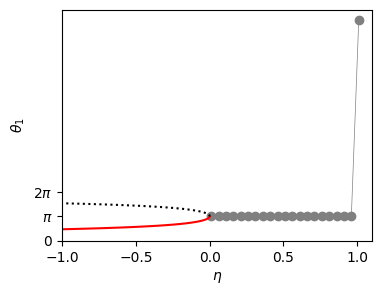

In [4]:
# load bifurcation data from XPPAUT for plotting
with open("Fig4_thetaIdent_bifurcation.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []

for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))

dat_theta_cpld = np.asarray(data)

fig = plt.figure(figsize=(4,3))
ax1 = fig.add_subplot()

#plot data from XPPAUT
id_SN = 0
id_SN_end = 61
ax1.plot(dat_theta_cpld[id_SN:id_SN_end,3],dat_theta_cpld[id_SN:id_SN_end,6],'-r')
id_us_end = 117
ax1.plot(dat_theta_cpld[id_SN_end:id_us_end,3],dat_theta_cpld[id_SN_end:id_us_end,6],':k')

# plot ghost branch
ax1.plot(paramVals, positions_ghosts[:,0],'-o',color='grey', lw=0.5, zorder=1)

ax1.set_ylabel(r"$\theta_1$")
ax1.set_xlabel(r"$\eta$")
ax1.set_xlim(-1,1.1)
ax1.set_yticks([0,np.pi,2*np.pi])
ax1.set_yticklabels(['0',r'$\pi$',r'$2\pi$']);

 For some reason `track_ghost_branch` identified a ghost elsewhere in phase space. To avoid this, we will additionally set `distQminThr=0.2`, which represents the maximum allowable distance between the last identified ghost and any slow points that are candidate ghosts. Any ghost candidate which exceeds this distance threshold is rejected, ensuring only candidate ghosts nearby in phase space are considered.

In [ ]:
positions_ghosts, paramVals, ghostSeqs =  gid.track_ghost_branch(ghost_start, coupledThetaNeurons, parameters_theta, 0, 20, 0.05, 25, dt, 
                                                                 delta=0.35, qmin_glob_options={"seed":9,"n_samples":150},qmin_loc_method=None, 
                                                                 distQminThr=0.2)

Progress:  80.00% | param value=0.81000:  76%|███████▌  | 16/21 [00:12<00:03,  1.39it/s]

GhostID: Trajectory does not leave U_eps - stopping ghostID.


Progress: 100.00% | param value=1.01000: 100%|██████████| 21/21 [00:15<00:00,  1.32it/s]


: 

This time we find all ghosts are at the correct positions. Additionally we've colorcoded the ghost branch according to the trapping time that we extracted from the ghosts identified via `track_ghost_branch`:

-0.000674574


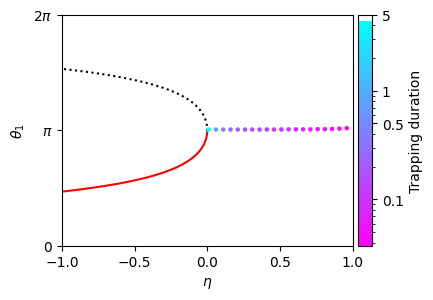

In [ ]:
# load bifurcation data from XPPAUT for plotting
with open("Fig4_thetaIdent_bifurcation.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []

for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))

dat_theta_cpld = np.asarray(data)

fig = plt.figure(figsize=(4,3))
ax1 = fig.add_subplot()

# plot data from XPPAUT
id_SN = 0
id_SN_end = 61
ax1.plot(dat_theta_cpld[id_SN:id_SN_end,3],dat_theta_cpld[id_SN:id_SN_end,6],'-r')
id_us_end = 117
ax1.plot(dat_theta_cpld[id_SN_end:id_us_end,3],dat_theta_cpld[id_SN_end:id_us_end,6],':k')
print(max(dat_theta_cpld[id_SN:id_SN_end,3]))

# extract trapping durations for color coding
trapping_durations = [ghostSeqs[i]["duration"] for i in range(len(ghostSeqs))]

# plot ghost branch
from matplotlib.colors import LogNorm
sc = ax1.scatter(paramVals, positions_ghosts[:,0], c=trapping_durations, marker='o', s=5, norm=LogNorm(), cmap='cool_r', zorder=2)

ax1.set_ylabel(r"$\theta_1$")
ax1.set_xlabel(r"$\eta$")
ax1.set_xlim(-1,1)
ax1.set_yticks([0,np.pi,2*np.pi])
ax1.set_yticklabels(['0',r'$\pi$',r'$2\pi$']);

# Add colorbar
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.05)
cb = plt.colorbar(sc, cax=cax, label='Trapping duration')
cb.set_ticks([1, 0.1, 0.5, 5])
cb.set_ticklabels(['1', '0.1', '0.5', '5'])


## Troubleshooting, non-attracting ghosts and tracking ghosts versus two parameters

Depending on the model and on which parameter is changed, tracking a ghost versus changing parameters can be difficult. We recommend to also check out the code from [Koch & Nandan 2026](http://arxiv.org/abs/2604.05194) available on the github repository for other examples as well as the API Reference for `track_ghost_branch`.

Currently `track_ghost_branch` does not support tracking of non-attracting ghosts versus parameters or tracking of ghosts while changing two parameters simultaneously. However, in some cases both tasks can be achieved manually using the `ghostID` function. See [Koch & Nandan 2026](http://arxiv.org/abs/2604.05194)
 for examples.